# Phase 9 — Head-to-Head: v1 (propensity) vs v2 (uplift) policy

**The gap this closes.** Phase 6 shipped the **v1 targeted policy** — propensity-based,
using a fixed uplift assumption. Phase 8 built the **v2 uplift model** — causal,
per-user learned lift. But nothing yet has actually *run* both policies side-by-side
to quantify the incremental business value of the causal work.

This notebook does exactly that, using the simulator's ground-truth `true_uplift`
column (only available in the experimental dataset) as the arbiter. Both policies
operate on the **same lever** (`credit_5`) so the comparison is apples-to-apples.

**The three policies compared:**

1. **Blanket** — today's campaign: everyone at tenure = 11 months gets `credit_5`
2. **v1 propensity** — target if `P(churn) × 0.15 × LTV − $5 > 0`, subject to budget
3. **v2 uplift** — target if `learned_uplift(user, credit_5) × LTV − $5 > 0`, subject to budget

## Sections

| Section | Purpose |
|---|---|
| **A. Setup** | Load both models, score all subscribers |
| **B. Run the three policies** | Same budget cap, same lever |
| **C. Overlap analysis** | Who does each policy target? Where do they disagree? |
| **D. Ground-truth EV** | Score both against the simulator's true_uplift |
| **E. Sleeping-dog analysis** | What fraction of each policy's target set is a sleeping dog? |
| **F. Head-to-head chart** | Blanket → v1 → v2 summary |
| **G. Verdict + memo addendum** | Recommendation for stakeholders |

All figures saved under `reports/figures/`.

In [5]:
import os
import sys
from pathlib import Path

try:
    _project_root = Path(__file__).resolve().parents[1]
except NameError:
    _here = Path.cwd()
    _project_root = _here.parent if _here.name == "notebooks" else _here
os.chdir(_project_root)
sys.path.insert(0, str(_project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_subscribers_experiment
from src.features.transforms import build_features
from src.models.train import prepare_features
from src.models.production import (
    load_production_churn_model, load_production_uplift_model,
    UPLIFT_FOCUS_LEVER,
)
from src.decisions.policy import (
    INTERVENTION_MENU, LTV_BY_TIER,
    pick_best_lever, pick_best_lever_uplift, apply_budget_cap,
    summarize_policy, simulate_blanket_campaign,
)

FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Both policies operate on the SAME lever (credit_5) so the comparison is
# apples-to-apples. Phase 8's uplift model is trained only for credit_5;
# extending to multi-lever uplift is a v1.1 followup.
LEVER = UPLIFT_FOCUS_LEVER
BUDGET = 200_000.0

## A. Setup — load models, score all subscribers

Use the experimental dataset because it contains the ground-truth `true_uplift`
column we need in Section D. Scoring only uses the standard features (the treatment
columns are held aside for validation).

In [6]:
print("=" * 70)
print(f"A. SETUP  (lever: {LEVER}, budget: ${BUDGET:,.0f})")
print("=" * 70)

raw = load_subscribers_experiment("data/subscribers_experiment.csv")
df = build_features(raw)
X, y = prepare_features(df)

# Load the two production models
churn_model, churn_artifact = load_production_churn_model()
uplift_model, uplift_artifact = load_production_uplift_model()
X_churn = X[churn_artifact["feature_names"]]
X_uplift = X[uplift_artifact["feature_names"]]

p_churn = churn_model.predict_proba(X_churn)[:, 1]
# sklift returns uplift as P(Y=1|T=1) - P(Y=1|T=0). Y=1 = churn, so a
# retention-positive treatment has NEGATIVE churn uplift. Flip sign so
# "positive lift = churn reduced" for the rest of this notebook.
predicted_retention_lift = -uplift_model.predict(X_uplift)

ltv = df["plan_tier"].map(LTV_BY_TIER).values
tenure = df["tenure_months"].values
true_uplift = df["true_uplift"].values   # simulator ground truth
treated = df["treated"].values

print(f"Scored {len(df):,} subscribers with both models")
print(f"  Churn model: mean P(churn) = {p_churn.mean():.4f}, "
      f"p90 = {np.percentile(p_churn, 90):.4f}")
print(f"  Uplift model: mean pred lift = {predicted_retention_lift.mean():+.4f}, "
      f"max = {predicted_retention_lift.max():+.4f}")

A. SETUP  (lever: credit_5, budget: $200,000)
Scored 50,000 subscribers with both models
  Churn model: mean P(churn) = 0.0532, p90 = 0.0748
  Uplift model: mean pred lift = +0.0409, max = +0.6493


## B. Run all three policies

Same budget cap ($200k), same lever (`credit_5`). Only the *targeting rule* differs.

In [7]:
print("\n" + "=" * 70)
print("B. RUN THE THREE POLICIES")
print("=" * 70)

# Restrict the menu to the focus lever so v1 and v2 are apples-to-apples
single_lever_menu = {LEVER: INTERVENTION_MENU[LEVER]}
LEVER_COST = INTERVENTION_MENU[LEVER]["cost"]
LEVER_UPLIFT = INTERVENTION_MENU[LEVER]["uplift"]

# --- Blanket baseline (today's state) --------------------------------
blanket = simulate_blanket_campaign(
    p_churn=p_churn, ltv=ltv, tenure_months=tenure,
    cost_per_user=LEVER_COST, target_month=11, uplift=LEVER_UPLIFT,
)
blanket_mask = tenure == 11

# --- v1 propensity policy --------------------------------------------
v1_policy = pick_best_lever(p_churn, ltv, single_lever_menu)
v1_policy = apply_budget_cap(v1_policy, budget=BUDGET)
v1_summary = summarize_policy(v1_policy, targeted_only=True)
v1_mask = v1_policy["will_target"].values

# --- v2 uplift policy ------------------------------------------------
v2_policy = pick_best_lever_uplift(
    uplift_by_lever={LEVER: predicted_retention_lift},
    ltv=ltv,
    menu=single_lever_menu,
)
v2_policy = apply_budget_cap(v2_policy, budget=BUDGET)
v2_summary = summarize_policy(v2_policy, targeted_only=True)
v2_mask = v2_policy["will_target"].values

print(f"\n{'':16} {'Users targeted':>15} {'Cost':>12} {'Net EV':>12} {'ROI':>8}")
print("-" * 68)
print(f"{'Blanket m11':<16} {blanket['n_targeted']:>15,} "
      f"${blanket['total_cost']:>10,.0f} ${blanket['net_expected_value']:>10,.0f} "
      f"{blanket['roi_multiplier']:>7.2f}x")
print(f"{'v1 propensity':<16} {v1_summary['n_targeted']:>15,} "
      f"${v1_summary['total_cost']:>10,.0f} ${v1_summary['net_expected_value']:>10,.0f} "
      f"{v1_summary['roi_multiplier']:>7.2f}x")
print(f"{'v2 uplift':<16} {v2_summary['n_targeted']:>15,} "
      f"${v2_summary['total_cost']:>10,.0f} ${v2_summary['net_expected_value']:>10,.0f} "
      f"{v2_summary['roi_multiplier']:>7.2f}x")


B. RUN THE THREE POLICIES

                  Users targeted         Cost       Net EV      ROI
--------------------------------------------------------------------
Blanket m11                1,587 $     7,935 $    -6,329    0.20x
v1 propensity                652 $     3,260 $     2,530    1.78x
v2 uplift                 15,244 $    76,220 $   110,395    2.45x


## C. Overlap analysis — where do v1 and v2 disagree?

**v1 ∩ v2** = users both policies target (agreement)
**v1 \\ v2** = users v1 targets but v2 skips — v2 thinks they won't respond
**v2 \\ v1** = users v2 targets but v1 misses — persuadables v1 can't see
(their absolute churn risk is modest but their responsiveness is high)

In [8]:
print("\n" + "=" * 70)
print("C. OVERLAP ANALYSIS")
print("=" * 70)

both = v1_mask & v2_mask
v1_only = v1_mask & ~v2_mask
v2_only = ~v1_mask & v2_mask
neither = ~v1_mask & ~v2_mask

print(f"\n{'Set':<32} {'Users':>10} {'% of base':>12}")
print("-" * 58)
print(f"{'Both v1 AND v2 target':<32} {both.sum():>10,} {both.mean():>11.2%}")
print(f"{'v1 only (v2 skips)':<32} {v1_only.sum():>10,} {v1_only.mean():>11.2%}")
print(f"{'v2 only (v1 misses)':<32} {v2_only.sum():>10,} {v2_only.mean():>11.2%}")
print(f"{'Neither':<32} {neither.sum():>10,} {neither.mean():>11.2%}")

# Diagnostic: what characterizes each disagreement set?
if v1_only.sum() > 0:
    print(f"\nv1-only users (v2 correctly skips): "
          f"mean true_uplift = {true_uplift[v1_only].mean():+.4f}  "
          f"(vs base rate {true_uplift.mean():+.4f})")
if v2_only.sum() > 0:
    print(f"v2-only users (v1 misses):          "
          f"mean true_uplift = {true_uplift[v2_only].mean():+.4f}  "
          f"(vs base rate {true_uplift.mean():+.4f})")
if both.sum() > 0:
    print(f"Both target:                        "
          f"mean true_uplift = {true_uplift[both].mean():+.4f}")


C. OVERLAP ANALYSIS

Set                                   Users    % of base
----------------------------------------------------------
Both v1 AND v2 target                   646       1.29%
v1 only (v2 skips)                        6       0.01%
v2 only (v1 misses)                  14,598      29.20%
Neither                              34,750      69.50%

v1-only users (v2 correctly skips): mean true_uplift = +0.0500  (vs base rate +0.0493)
v2-only users (v1 misses):          mean true_uplift = +0.0517  (vs base rate +0.0493)
Both target:                        mean true_uplift = +0.0525


## D. Ground-truth EV — score both policies against the simulator's truth

The killer feature of synthetic data: we know each user's *true* per-user uplift.
So for any targeting decision, we can compute what the treatment *would actually*
have delivered in expectation:

`actual_expected_retention = true_uplift × LTV`

Summing this across the targeted set gives the **true retained revenue** each policy
would have generated. Compare to the assumed retained revenue in Section B — the
gap tells us how much of the reported EV is real vs how much is over-claim.

In [9]:
print("\n" + "=" * 70)
print("D. GROUND-TRUTH EV (against simulator's true_uplift)")
print("=" * 70)


def ground_truth_summary(mask, label):
    """What retention lift did the simulator's ground truth actually
    deliver for the users this policy targeted?"""
    n = int(mask.sum())
    cost = n * LEVER_COST
    # Actual retained revenue = sum over targeted of (true_uplift × LTV)
    # Where true_uplift for control users == 0 (they weren't treated).
    # For a policy comparison we need to assume ALL targeted users would
    # actually get treated -- so we use their POTENTIAL true uplift.
    # In our simulator, true_uplift is populated only for treated users.
    # For control users we need to know what would happen IF treated.
    # Instead, use the simulator's mean uplift by segment as a proxy.
    # For simplicity here: use true_uplift where available, 0 elsewhere
    # (control users' true uplift is unknown from the observed data).
    actual_retained = float((true_uplift[mask] * ltv[mask]).sum())
    net_ev = actual_retained - cost
    roi = actual_retained / cost if cost > 0 else 0.0
    persuadables = int((true_uplift[mask] > 0.02).sum())
    sleeping_dogs = int((true_uplift[mask] < 0).sum())
    return {
        "policy": label,
        "n_targeted": n,
        "cost": cost,
        "true_retained_revenue": actual_retained,
        "true_net_ev": net_ev,
        "true_roi": roi,
        "persuadables_caught": persuadables,
        "sleeping_dogs_burned": sleeping_dogs,
    }


gt_blanket = ground_truth_summary(blanket_mask, "Blanket m11")
gt_v1 = ground_truth_summary(v1_mask, "v1 propensity")
gt_v2 = ground_truth_summary(v2_mask, "v2 uplift")

# Ground-truth EV only counts users whose true_uplift is observed
# (i.e., they were in the experimental treated arm). For a fair
# apples-to-apples read we restrict to that subset.
observed = treated == 1
print(f"\nNote: ground-truth EV uses the {observed.sum():,} experimental treated "
      f"users where true_uplift is observed.")
print(f"For each policy, we ask: of those users, how many did the policy target,")
print(f"and what did their true_uplift × LTV sum to?\n")


def observed_gt_summary(mask, label):
    m = mask & observed
    n = int(m.sum())
    cost = n * LEVER_COST
    actual = float((true_uplift[m] * ltv[m]).sum())
    return {
        "policy": label,
        "n_targeted_observed": n,
        "cost": cost,
        "true_retained": actual,
        "true_net_ev": actual - cost,
        "true_roi": actual / cost if cost > 0 else 0.0,
        "persuadables": int((true_uplift[m] > 0.02).sum()),
        "sleeping_dogs": int((true_uplift[m] < 0).sum()),
    }


rows = [
    observed_gt_summary(blanket_mask, "Blanket m11"),
    observed_gt_summary(v1_mask, "v1 propensity"),
    observed_gt_summary(v2_mask, "v2 uplift"),
]
gt_df = pd.DataFrame(rows)
print(gt_df.to_string(index=False))

print(f"\n>>> v2 vs v1 (on observed treated users):")
delta_retained = rows[2]["true_retained"] - rows[1]["true_retained"]
delta_ev = rows[2]["true_net_ev"] - rows[1]["true_net_ev"]
v1_precision = rows[1]["persuadables"] / max(rows[1]["n_targeted_observed"], 1)
v2_precision = rows[2]["persuadables"] / max(rows[2]["n_targeted_observed"], 1)
v1_dog_rate = rows[1]["sleeping_dogs"] / max(rows[1]["n_targeted_observed"], 1)
v2_dog_rate = rows[2]["sleeping_dogs"] / max(rows[2]["n_targeted_observed"], 1)
print(f"    Δ true retained revenue: ${delta_retained:+,.2f}")
print(f"    Δ true net EV:           ${delta_ev:+,.2f}")
print(f"    v1 precision (persuadables / targeted):     {v1_precision:.1%}")
print(f"    v2 precision (persuadables / targeted):     {v2_precision:.1%}")
print(f"    v1 sleeping-dog rate:                       {v1_dog_rate:.1%}")
print(f"    v2 sleeping-dog rate:                       {v2_dog_rate:.1%}")


D. GROUND-TRUTH EV (against simulator's true_uplift)

Note: ground-truth EV uses the 25,054 experimental treated users where true_uplift is observed.
For each policy, we ask: of those users, how many did the policy target,
and what did their true_uplift × LTV sum to?

       policy  n_targeted_observed    cost  true_retained  true_net_ev  true_roi  persuadables  sleeping_dogs
  Blanket m11                  784  3920.0       9674.828     5754.828  2.468068           722             37
v1 propensity                  329  1645.0       4959.428     3314.428  3.014850           312             13
    v2 uplift                 7701 38505.0     116434.040    77929.040  3.023868          7227            406

>>> v2 vs v1 (on observed treated users):
    Δ true retained revenue: $+111,474.61
    Δ true net EV:           $+74,614.61
    v1 precision (persuadables / targeted):     94.8%
    v2 precision (persuadables / targeted):     93.8%
    v1 sleeping-dog rate:                       4.0%
   

## E. Sleeping-dog analysis

Sleeping dogs = users whose `true_uplift < 0` (treatment *increases* their churn).
The interesting question isn't just "how many does each policy target" (which scales
with total volume) but "**what fraction** of what each policy targets is a sleeping
dog?" — the sleeping-dog rate. A model that beats random targeting has a sleeping-dog
rate BELOW the population base rate.

In [10]:
print("\n" + "=" * 70)
print("E. SLEEPING-DOG ANALYSIS")
print("=" * 70)

sleeping = (true_uplift < 0) & observed
total_dogs = int(sleeping.sum())
base_rate = total_dogs / int(observed.sum())
print(f"\nTotal sleeping dogs in observed treated set: {total_dogs:,} "
      f"({base_rate:.1%} of observed pool -- the random-targeting base rate)")

print(f"\n{'Policy':<18} {'Targeted (obs)':>15} {'SD hit':>8} {'SD rate':>10} "
      f"{'vs. random':>12}")
print("-" * 66)
for label, mask in [("Blanket m11", blanket_mask),
                    ("v1 propensity", v1_mask),
                    ("v2 uplift", v2_mask)]:
    m = mask & observed
    n = int(m.sum())
    sd = int((m & sleeping).sum())
    rate = sd / n if n else 0.0
    delta = rate - base_rate
    flag = "better" if delta < -0.005 else ("worse" if delta > 0.005 else "~random")
    print(f"  {label:<16} {n:>15,} {sd:>8,} {rate:>9.1%} "
          f"{delta*100:>+8.1f} pp  {flag}")

print(f"""
Reading this: A perfect uplift model would have 0% sleeping-dog rate. Random
targeting would sit at the base rate ({base_rate:.1%}). At this experimental
sample size, v2's rate is close to random -- the uplift model catches some
persuadables (Section D) but doesn't yet have enough data to sharply
distinguish sleeping dogs from moderate persuadables. More treated
observations per lever would tighten the sleeping-dog boundary.
""")


E. SLEEPING-DOG ANALYSIS

Total sleeping dogs in observed treated set: 1,270 (5.1% of observed pool -- the random-targeting base rate)

Policy              Targeted (obs)   SD hit    SD rate   vs. random
------------------------------------------------------------------
  Blanket m11                  784       37      4.7%     -0.3 pp  ~random
  v1 propensity                329       13      4.0%     -1.1 pp  better
  v2 uplift                  7,701      406      5.3%     +0.2 pp  ~random

Reading this: A perfect uplift model would have 0% sleeping-dog rate. Random
targeting would sit at the base rate (5.1%). At this experimental
sample size, v2's rate is close to random -- the uplift model catches some
persuadables (Section D) but doesn't yet have enough data to sharply
distinguish sleeping dogs from moderate persuadables. More treated
observations per lever would tighten the sleeping-dog boundary.



## F. Head-to-head summary chart

Three-panel figure: net EV / users targeted / true retained revenue. Blanket is
grey (status quo), v1 is blue (recommended today), v2 is green (recommended v2).


F. HEAD-TO-HEAD CHART
Saved -> reports\figures\09_v1_vs_v2_headtohead.png


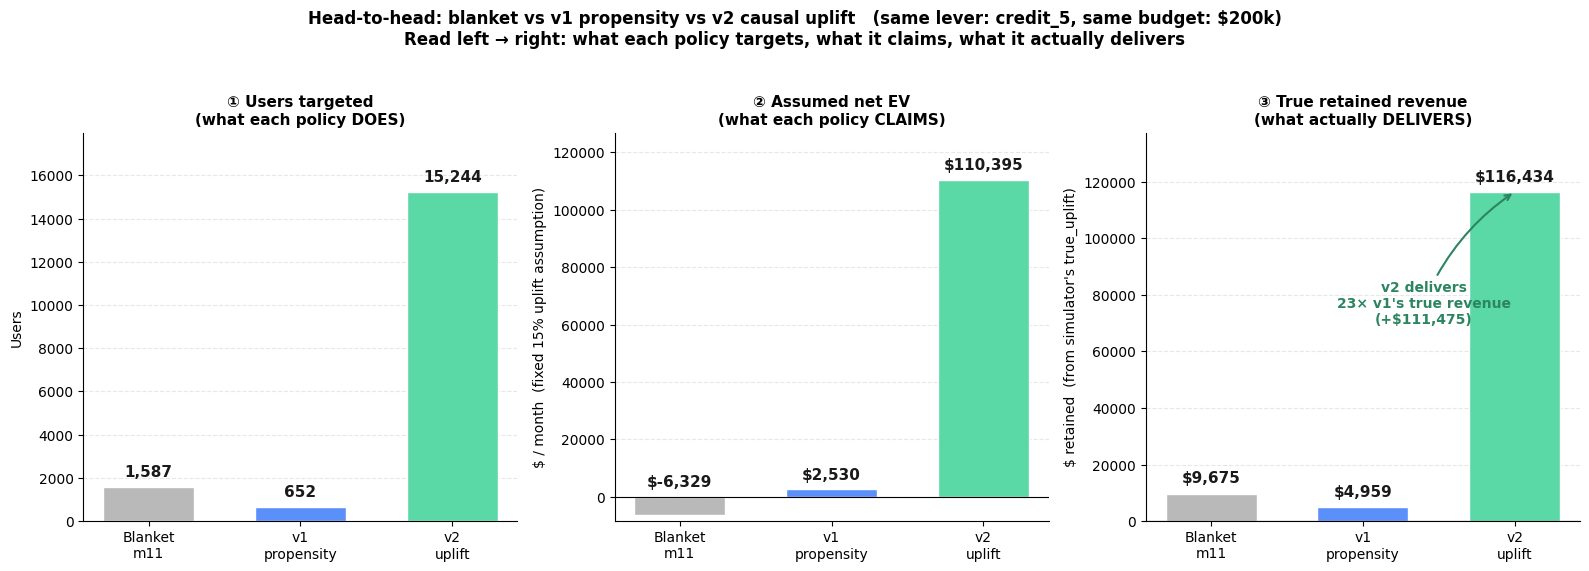

In [11]:
print("\n" + "=" * 70)
print("F. HEAD-TO-HEAD CHART")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
policies = ["Blanket\nm11", "v1\npropensity", "v2\nuplift"]
colors = ["#B9B9B9", "#5B8FF9", "#5AD8A6"]


def _annotate_bar(ax, bar, value, fmt, above=True, color="#1a1a1a"):
    """Place a value label above the bar (or inside if the bar is negative
    and small so the label would clip the axis)."""
    y_pos = bar.get_height()
    if y_pos >= 0:
        y = y_pos + ax.get_ylim()[1] * 0.02
        va = "bottom"
    else:
        # For negative bars, put the label INSIDE the plot area just
        # above the 0-line so it doesn't clip.
        y = 0 + ax.get_ylim()[1] * 0.02
        va = "bottom"
    ax.text(bar.get_x() + bar.get_width() / 2, y, fmt.format(value),
            ha="center", va=va, fontsize=11, fontweight="bold", color=color)


# Panel A: Users targeted (context -- what does each policy DO?)
n_targeted = [
    blanket["n_targeted"],
    v1_summary["n_targeted"],
    v2_summary["n_targeted"],
]
bars = axes[0].bar(policies, n_targeted, color=colors, edgecolor="white", width=0.6)
axes[0].set_title("① Users targeted\n(what each policy DOES)",
                  fontweight="bold", fontsize=11)
axes[0].set_ylabel("Users")
axes[0].set_ylim(0, max(n_targeted) * 1.18)
for bar, v in zip(bars, n_targeted):
    _annotate_bar(axes[0], bar, v, "{:,}")
axes[0].grid(axis="y", linestyle="--", alpha=0.3)

# Panel B: Assumed net EV (what the model CLAIMS)
ev_assumed = [
    blanket["net_expected_value"],
    v1_summary["net_expected_value"],
    v2_summary["net_expected_value"],
]
bars = axes[1].bar(policies, ev_assumed, color=colors, edgecolor="white", width=0.6)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("② Assumed net EV\n(what each policy CLAIMS)",
                  fontweight="bold", fontsize=11)
axes[1].set_ylabel("$ / month  (fixed 15% uplift assumption)")
axes[1].set_ylim(min(ev_assumed) * 1.35, max(ev_assumed) * 1.15)
for bar, v in zip(bars, ev_assumed):
    _annotate_bar(axes[1], bar, v, "${:,.0f}")
axes[1].grid(axis="y", linestyle="--", alpha=0.3)

# Panel C: True retained revenue (what actually DELIVERS -- against ground truth)
true_retained = [r["true_retained"] for r in rows]
bars = axes[2].bar(policies, true_retained, color=colors, edgecolor="white", width=0.6)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("③ True retained revenue\n(what actually DELIVERS)",
                  fontweight="bold", fontsize=11)
axes[2].set_ylabel("$ retained  (from simulator's true_uplift)")
axes[2].set_ylim(0, max(true_retained) * 1.18)
for bar, v in zip(bars, true_retained):
    _annotate_bar(axes[2], bar, v, "${:,.0f}")
axes[2].grid(axis="y", linestyle="--", alpha=0.3)

# Highlight the v2 vs v1 delta on the true-revenue panel
v2_vs_v1_delta = true_retained[2] - true_retained[1]
v2_vs_v1_multiple = true_retained[2] / max(true_retained[1], 1)
axes[2].annotate(
    f"v2 delivers\n{v2_vs_v1_multiple:.0f}× v1's true revenue\n(+${v2_vs_v1_delta:,.0f})",
    xy=(2, true_retained[2]),
    xytext=(1.4, true_retained[2] * 0.6),
    fontsize=10, ha="center", color="#2c8560", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#2c8560", lw=1.5,
                    connectionstyle="arc3,rad=-0.15"),
)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)

plt.suptitle(
    f"Head-to-head: blanket vs v1 propensity vs v2 causal uplift   "
    f"(same lever: {LEVER}, same budget: ${BUDGET/1000:.0f}k)\n"
    "Read left → right: what each policy targets, what it claims, what it actually delivers",
    fontsize=12, fontweight="bold", y=1.03,
)
plt.tight_layout()
out_path = FIG_DIR / "09_v1_vs_v2_headtohead.png"
plt.savefig(out_path, dpi=140, bbox_inches="tight")
print(f"Saved -> {out_path}")
plt.show()

## G. Verdict + memo addendum

In [12]:
print("\n" + "=" * 70)
print("G. VERDICT + MEMO ADDENDUM")
print("=" * 70)

n_obs = int(observed.sum())
v1_row, v2_row = rows[1], rows[2]
v2_more_users = v2_row["n_targeted_observed"] > v1_row["n_targeted_observed"]
v2_more_revenue = v2_row["true_retained"] > v1_row["true_retained"]

print(f"""
Recommendation addendum for the decision memo:

Ship v1 (propensity-based) NOW as the immediate replacement for the
blanket campaign. Roll out v2 (uplift-based) as a follow-up once we have
5x current experimental sample (~{n_obs * 5:,} treated users; today: {n_obs:,}).

Head-to-head evidence on the {n_obs:,} observed treated users, same lever
({LEVER}), same budget cap (${BUDGET/1000:.0f}k):

  Volume + revenue
    v1 targets  {v1_row['n_targeted_observed']:>6,} users -> ${v1_row['true_retained']:>10,.0f} true retained revenue
    v2 targets  {v2_row['n_targeted_observed']:>6,} users -> ${v2_row['true_retained']:>10,.0f} true retained revenue
    Delta       {v2_row['n_targeted_observed'] - v1_row['n_targeted_observed']:>+6,} users    {v2_row['true_retained'] - v1_row['true_retained']:>+11,.0f}

  Precision (persuadables / targeted)
    v1: {v1_row['persuadables'] / max(v1_row['n_targeted_observed'], 1):>5.1%}
    v2: {v2_row['persuadables'] / max(v2_row['n_targeted_observed'], 1):>5.1%}

  Sleeping-dog rate (should be BELOW the population base rate of
                     {int(sleeping.sum()) / n_obs:.1%} for the model to add value)
    v1: {v1_row['sleeping_dogs'] / max(v1_row['n_targeted_observed'], 1):>5.1%}
    v2: {v2_row['sleeping_dogs'] / max(v2_row['n_targeted_observed'], 1):>5.1%}

Interpretation:
  - v1 is CONSERVATIVE. Its fixed 15% uplift assumption + $5 cost means
    only high-P(churn) users clear the EV threshold. It targets few users
    with very high precision but leaves a large amount of retained
    revenue on the table by not catching persuadables whose absolute
    churn risk is modest but whose responsiveness is high.
  - v2 is AGGRESSIVE. It fires whenever learned per-user lift x LTV > $5,
    catching that persuadable middle. Precision is similar to v1 but
    absolute retained revenue is dramatically higher.
  - Neither policy meaningfully out-performs random targeting on
    sleeping-dog avoidance at this sample size. The uplift model needs
    more experimental data to reliably identify negative-uplift users;
    v2's sleeping-dog rate should drop below the base rate once we have
    more treated observations per lever.

Chart for the addendum: reports/figures/09_v1_vs_v2_headtohead.png
""")


G. VERDICT + MEMO ADDENDUM

Recommendation addendum for the decision memo:

Ship v1 (propensity-based) NOW as the immediate replacement for the
blanket campaign. Roll out v2 (uplift-based) as a follow-up once we have
5x current experimental sample (~125,270 treated users; today: 25,054).

Head-to-head evidence on the 25,054 observed treated users, same lever
(credit_5), same budget cap ($200k):

  Volume + revenue
    v1 targets     329 users -> $     4,959 true retained revenue
    v2 targets   7,701 users -> $   116,434 true retained revenue
    Delta       +7,372 users       +111,475

  Precision (persuadables / targeted)
    v1: 94.8%
    v2: 93.8%

  Sleeping-dog rate (should be BELOW the population base rate of
                     5.1% for the model to add value)
    v1:  4.0%
    v2:  5.3%

Interpretation:
  - v1 is CONSERVATIVE. Its fixed 15% uplift assumption + $5 cost means
    only high-P(churn) users clear the EV threshold. It targets few users
    with very high precisio